In [1]:
# Compute Minkowski distance between two vectors
from scipy.spatial import minkowski_distance

# Define new data
array1 = [3, 7, 14, 21, 30]
array2 = [5, 10, 18, 25, 35]

# Calculate Minkowski distance (p=1)
dist1 = minkowski_distance(array1, array2, 1)
print("Minkowski Distance (p=1):", dist1)

# Calculate Minkowski distance (p=2)
dist2 = minkowski_distance(array1, array2, 2)
print("Minkowski Distance (p=2):", dist2)


Minkowski Distance (p=1): 18.0
Minkowski Distance (p=2): 8.366600265340756


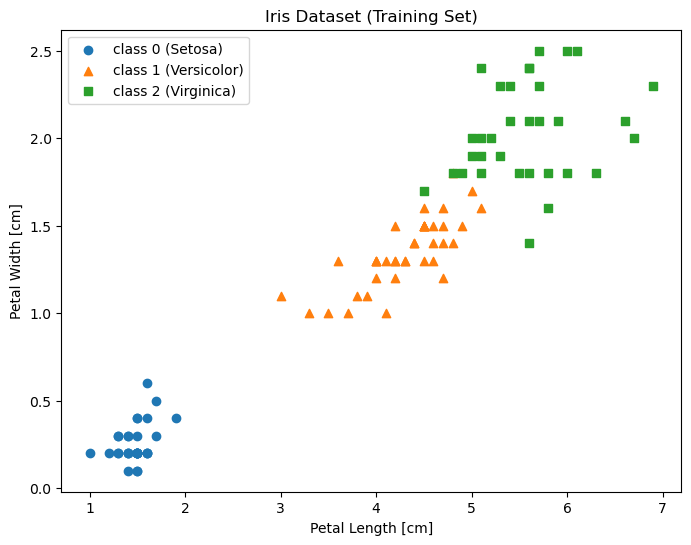

Test set accuracy: 95.56%


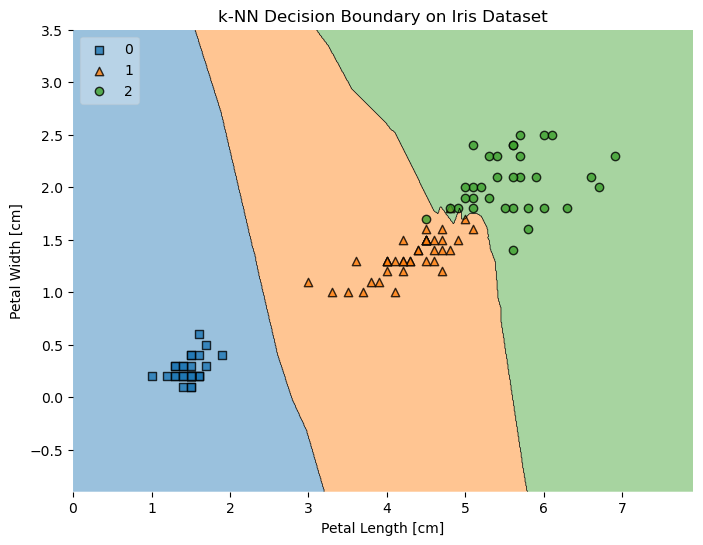

In [5]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.plotting import plot_decision_regions

# Load the Iris dataset from sklearn (already optimized)
iris = load_iris()
X, y = iris.data[:, 2:], iris.target

# Split the dataset into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, shuffle=True)

# Visualize the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], marker='o', label='class 0 (Setosa)')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], marker='^', label='class 1 (Versicolor)')
plt.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1], marker='s', label='class 2 (Virginica)')
plt.xlabel('Petal Length [cm]')
plt.ylabel('Petal Width [cm]')
plt.legend(loc='upper left')
plt.title('Iris Dataset (Training Set)')
plt.show()

# Fit k-Nearest Neighbors classifier with k=3
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(X_train, y_train)

# Predict on the test set and calculate accuracy
y_pred = knn_model.predict(X_test)
accuracy = np.mean(y_pred == y_test) * 100
print(f'Test set accuracy: {accuracy:.2f}%')

# Visualize the decision boundary
plt.figure(figsize=(8, 6))
plot_decision_regions(X_train, y_train, clf=knn_model, legend=2)
plt.xlabel('Petal Length [cm]')
plt.ylabel('Petal Width [cm]')
plt.title('k-NN Decision Boundary on Iris Dataset')
plt.show()




Gaussian Naive Bayes Accuracy: 0.9778
Decision Tree Accuracy: 0.9778
Support Vector Machine Accuracy: 0.9778


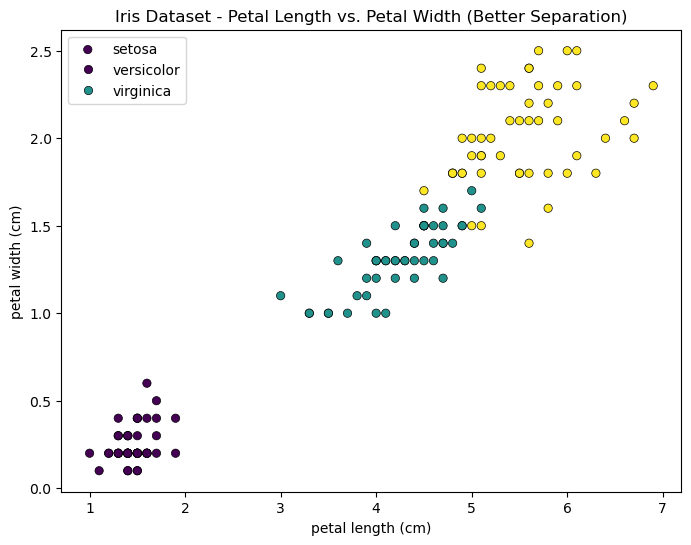

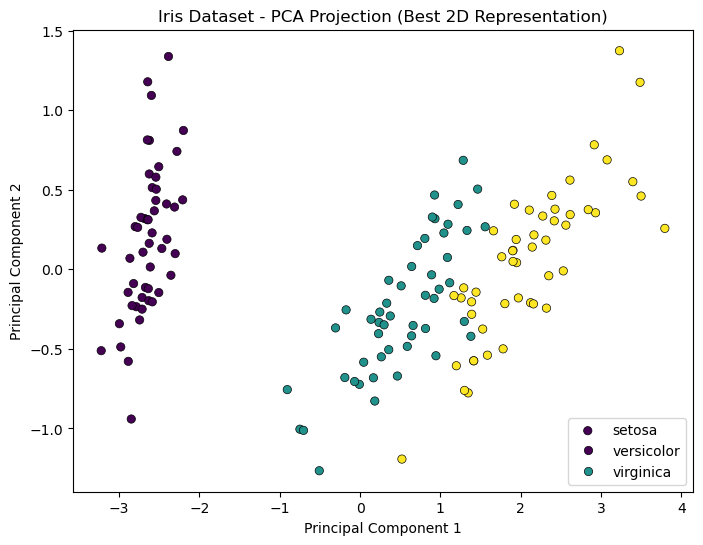

In [25]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

# Load the iris dataset
iris = datasets.load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Convert to a Pandas DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['species'] = y

# Split data into training and testing sets (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

# Define models
models = {
    "Gaussian Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=1),
    "Support Vector Machine": SVC(kernel='linear', random_state=1)
}

# Function to train and evaluate models
def train_evaluate(models, X_train, X_test, y_train, y_test):
    for name, model in models.items():
        model.fit(X_train, y_train)  # Train model
        predictions = model.predict(X_test)  # Make predictions
        accuracy = accuracy_score(y_test, predictions)  # Calculate accuracy
        print(f"{name} Accuracy: {accuracy:.4f}")

# Train and evaluate models
train_evaluate(models, X_train, X_test, y_train, y_test)

# 🌟 Plot 1: Scatter Plot with Improved Feature Selection (Petal Length vs. Petal Width)
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df[feature_names[2]], y=df[feature_names[3]], hue=df['species'], palette="viridis", edgecolor="k")
plt.xlabel(feature_names[2])  # Petal Length
plt.ylabel(feature_names[3])  # Petal Width
plt.title("Iris Dataset - Petal Length vs. Petal Width (Better Separation)")
plt.legend(labels=target_names)
plt.show()

# 🌟 Plot 2: Pairplot for Complete Feature Exploration
#sns.pairplot(df, hue='species', palette="viridis")
#plt.suptitle("Pairplot of All Features", y=1.02)
#plt.show()

# 🌟 Plot 3: PCA for Better 2D Representation
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="viridis", edgecolor="k")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Iris Dataset - PCA Projection (Best 2D Representation)")
plt.legend(labels=target_names)
plt.show()
